In [1]:
import numpy as np
import scipy.io
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns


from modules import *

plt.rcParams['font.size'] = 14
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['font.family'] = 'Arial'

In [ ]:
# load the .mat file
data = scipy.io.loadmat('data/allchoicetrials.mat')
print(data.keys())

offered = np.array(data['offered'], dtype = int)
chosen = np.array(data['chosen'], dtype = int).squeeze()
unchosen = np.array(data['unchosen'], dtype = int).squeeze()
posteriors = np.array(data['posteriors'], dtype = float).squeeze()
classification = np.array(data['classification'], dtype = int)
time = np.array(data['time'], dtype = float)

print(offered.shape)
print(chosen.shape)
print(unchosen.shape)
print(posteriors.shape)
print(classification.shape)
print(time.shape)

dict_keys(['__header__', '__version__', '__globals__', 'time', 'M_offered', 'M_classifications', 'M_posteriors', 'M_chosen', 'N_classifications', 'N_posteriors', 'N_offered', 'N_chosen', 'N_notavailable', 'N_unchosen', 'M_notavailable', 'M_unchosen', 'posteriors', 'chosen', 'unchosen', 'classification', 'offered'])
(4739, 2)
(4739,)
(4739,)
(4739, 276, 4)
(4739, 276)
(276, 2)


In [ ]:
trial_numbers_M = [116, 122, 130, 133, 111, 105, 109, 100, 108, 129, 100, 114, 110, 99, 115, 114, 114, 103, 113, 99, 86, 107, 103, 99]
trial_numbers_N = [77, 130, 95, 91, 117, 112, 106, 97, 105, 126, 116, 97, 120, 100, 118, 110, 96, 90, 106, 91]
trial_numbers = np.array(trial_numbers_M + trial_numbers_N)

session = []
for i in range(len(trial_numbers)):
    session.append(np.repeat(i, trial_numbers[i]))
session = np.concatenate(session)

print(session.shape)

(4739,)


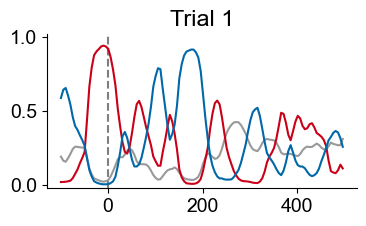

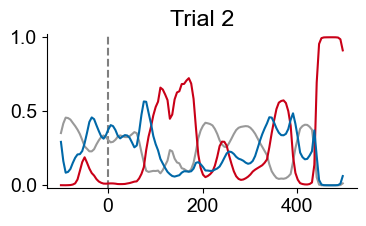

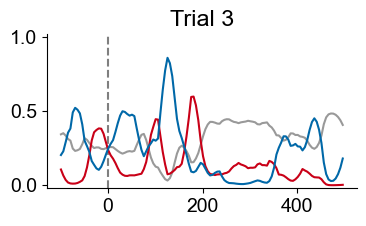

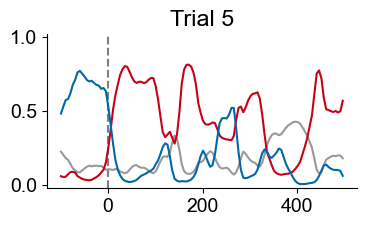

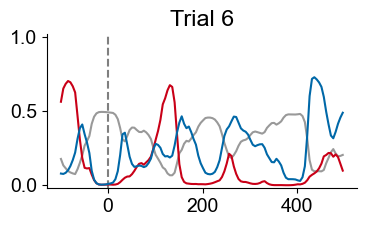

In [4]:
indices_unequal = np.where(chosen != unchosen)[0]

mid_time = np.nanmean(time, axis = 1)
indices_plot = np.where((mid_time >= -100) & (mid_time <= 500))[0]

for i in indices_unequal[:5]:

    # get index
    chosen_index = np.where(offered[i] == chosen[i])[0][0]
    unchosen_index = np.where(offered[i] == unchosen[i])[0][0]

    # get values
    value_chosen = offered[i, chosen_index]
    value_unchosen = offered[i, unchosen_index]
    unavailable_values = np.arange(1, 5)[(np.arange(1, 5) != value_chosen) & (np.arange(1, 5) != value_unchosen)]

    # get posterior sequences
    post_chosen = posteriors[i, indices_plot, value_chosen - 1]
    post_unchosen = posteriors[i, indices_plot, value_unchosen - 1]
    post_unavailable = posteriors[i, indices_plot][:, unavailable_values - 1].mean(axis = 1)

    plt.figure(figsize = (4, 2))
    plt.plot(mid_time[indices_plot], post_chosen, color = '#C90017', linewidth = 1.5)
    plt.plot(mid_time[indices_plot], post_unchosen, color = '#0068A8', linewidth = 1.5)
    plt.plot(mid_time[indices_plot], post_unavailable, color = '#999999', linewidth = 1.5, zorder = 0)
    plt.axvline(x = 0, color = 'k', linestyle = '--', alpha = 0.5, zorder = -1)
    plt.title(f'Trial {i}')
    plt.ylim(-0.02, 1.02)
    plt.show()

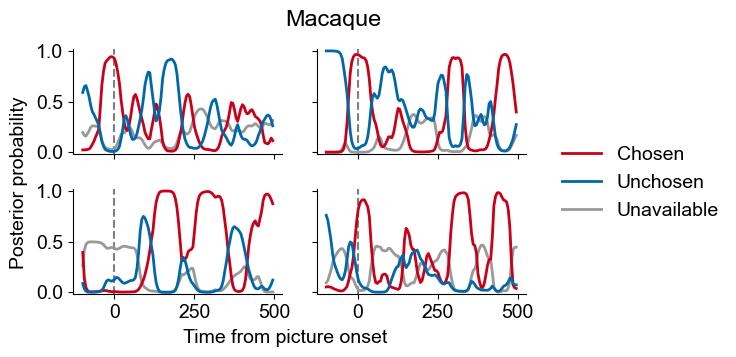

In [5]:
trials = [1, 151, 205, 61]

fig, axes = plt.subplots(2, 2, figsize = (5.4, 3.2), sharex = True, sharey = True)
axes = axes.flatten()

for ax, i in zip(axes, trials):
    # get index
    chosen_index = np.where(offered[i] == chosen[i])[0][0]
    unchosen_index = np.where(offered[i] == unchosen[i])[0][0]

    # get values
    value_chosen = offered[i, chosen_index]
    value_unchosen = offered[i, unchosen_index]
    unavailable_values = np.arange(1, 5)[(np.arange(1, 5) != value_chosen) & (np.arange(1, 5) != value_unchosen)]

    # get posterior sequences
    post_chosen = posteriors[i, indices_plot, value_chosen - 1]
    post_unchosen = posteriors[i, indices_plot, value_unchosen - 1]
    post_unavailable = posteriors[i, indices_plot][:, unavailable_values - 1].mean(axis=1)

    # plot
    ax.plot(mid_time[indices_plot], post_chosen, color = '#C90017', linewidth = 2, label = 'Chosen')
    ax.plot(mid_time[indices_plot], post_unchosen, color = '#0068A8', linewidth = 2, label = 'Unchosen')
    ax.plot(mid_time[indices_plot], post_unavailable, color = '#999999', linewidth = 2, zorder = 0, label = 'Unavailable')
    ax.axvline(x = 0, color = 'k', linestyle = '--', alpha = 0.5, zorder = -1)
    # ax.set_title(f'Trial {i}')
    ax.set_ylim(-0.02, 1.02)
    ax.set_yticks([0, 0.5, 1])

# Common x and y labels
fig.text(0.5, 0, 'Time from picture onset', ha = 'center', fontsize = 14)
fig.text(-0.01, 0.5, 'Posterior probability', va = 'center', rotation = 'vertical', fontsize = 14)
fig.text(0.5, 1.01, 'Macaque', va = 'center', fontsize = 16.8)

# One legend on the right
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc = 'center left', bbox_to_anchor = (0.98, 0.5), frameon = False)

plt.tight_layout()
# plt.show()
plt.savefig('figures/p_posterior.pdf', bbox_inches = 'tight')

## State count

In [28]:
indices_decode = np.where((time[:, 0] >= 0) & (time[:, 1] <= 800))[0]

num_states_chosen = []
num_states_unchosen = []
durations_chosen = []
durations_unchosen = []
session_id = []

for i in indices_unequal:

    # get indices
    chosen_index = np.where(offered[i] == chosen[i])[0][0]
    unchosen_index = np.where(offered[i] == unchosen[i])[0][0]

    # get values
    value_chosen = offered[i, chosen_index]
    value_unchosen = offered[i, unchosen_index]

    if chosen_index == unchosen_index:
        raise ValueError('Indices are the same.')

    # get posterior sequences
    post_chosen = posteriors[i, indices_decode, value_chosen - 1]
    post_unchosen = posteriors[i, indices_decode, value_unchosen - 1]

    # count states
    num_states_chosen_trial, durations_chosen_trial = count_states_and_lengths(post_chosen, min_length = 4, threshold = 0.5)
    num_states_unchosen_trial, durations_unchosen_trial = count_states_and_lengths(post_unchosen, min_length = 4, threshold = 0.5)

    # append results
    num_states_chosen.append(num_states_chosen_trial)
    num_states_unchosen.append(num_states_unchosen_trial)
    durations_chosen.append(durations_chosen_trial)
    durations_unchosen.append(durations_unchosen_trial)
    session_id.append(session[i])

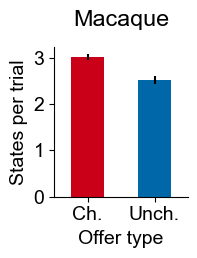

In [29]:
df = pd.DataFrame({
    'num_states_chosen': num_states_chosen,
    'num_states_unchosen': num_states_unchosen,
    'session_id': session_id,
})

df_grouped = df.groupby(['session_id']).mean().reset_index()
means = df_grouped.mean()
errors = df_grouped.std() / np.sqrt(len(np.unique(df['session_id'])))

plt.figure(figsize = (2.2, 2.8))
plt.bar(['Ch.', 'Unch.'], means[['num_states_chosen', 'num_states_unchosen']], color = ['#C90017', '#0068A8'], width = 0.5, yerr = errors[['num_states_chosen', 'num_states_unchosen']], capsize = 0)
plt.xlim(-0.5, 1.5)
# plt.ylim(0, 3.15)
plt.yticks([0, 1, 2, 3])
plt.xlabel('Offer type')
plt.ylabel('States per trial')
plt.title('Macaque', pad = 15)
plt.tight_layout()
# plt.show()
plt.savefig('figures/p_state_count.pdf', bbox_inches = 'tight')

In [8]:
from scipy.stats import ttest_rel

t_stat, p_value = ttest_rel(
    df_grouped['num_states_chosen'],
    df_grouped['num_states_unchosen']
)

print(f"t = {t_stat}, p = {p_value}")
print(len(df_grouped) - 1)

t = 5.234429667421069, p = 4.681651780570314e-06
43


## Number of transitions by value

In [22]:
num_transitions = []
values_chosen = []
values_unchosen = []
session_id = []

for i in indices_unequal:

    # get index
    chosen_index = np.where(offered[i] == chosen[i])[0][0]
    unchosen_index = np.where(offered[i] == unchosen[i])[0][0]

    # get values
    value_chosen = offered[i, chosen_index]
    value_unchosen = offered[i, unchosen_index]

    # get posterior sequences
    post_chosen = posteriors[i, indices_decode, value_chosen - 1]
    post_unchosen = posteriors[i, indices_decode, value_unchosen - 1]

    # get transitions
    n = count_transitions(np.stack([post_chosen, post_unchosen], axis = 1), min_length = 3, threshold = 0.5)
    if n >= 0:
        num_transitions.append(n)
        values_chosen.append(value_chosen)
        values_unchosen.append(value_unchosen)
        session_id.append(session[i])
        
# # prepare design matrix with intercept
# X = np.column_stack((values_chosen, values_unchosen))
# X = sm.add_constant(X)  # adds column of ones for intercept
# y = np.array(num_transitions)

# # fit OLS regression
# model = sm.OLS(y, X).fit()

# # get full statistical summary
# print(model.summary())

# # get p-values directly
# print('p-values:', model.pvalues)

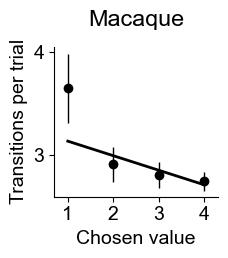

In [26]:
df = pd.DataFrame({
    'num_transitions': num_transitions,
    'values_chosen': values_chosen,
    'values_unchosen': values_unchosen,
    'session_id': session_id,
})

df_grouped = df.groupby(['values_chosen', 'session_id']).mean().reset_index()
means = df_grouped.groupby(['values_chosen']).mean().reset_index()
errors = (df_grouped.groupby(['values_chosen']).std() / np.sqrt(len(np.unique(df['session_id'])))).reset_index()

# ---- fit linear mixed model ----
# random intercepts per session
model = smf.mixedlm('num_transitions ~ values_chosen', df, groups = df['session_id'])
result = model.fit(reml = False)
# print(result.summary())
# ---- get fitted values for plotting ----
x_pred = np.linspace(1, 4, 200)
df_pred = pd.DataFrame({'values_chosen': x_pred})
df_pred['num_transitions'] = result.predict(df_pred)


plt.figure(figsize = (2.5, 2.8))
plt.errorbar(means['values_chosen'], means['num_transitions'], yerr = errors['num_transitions'], fmt = 'o', color = 'black', ecolor = 'black', elinewidth = 1, capsize = 0)
# sns.regplot(data = df, x = 'values_chosen', y = 'num_transitions', ci = False, scatter = False, color = 'k')
plt.plot(df_pred['values_chosen'], df_pred['num_transitions'], color = 'k', linewidth = 2)
plt.xlim((0.7, 4.3))
plt.xticks([1, 2, 3, 4])
plt.ylim((2.6, 4.05))
plt.yticks([3, 4])
plt.xlabel('Chosen value')
plt.ylabel('Transitions per trial')
plt.title('Macaque', pad = 15)
plt.tight_layout()
# plt.show()
plt.savefig('figures/p_num_transitions_by_chosen_value.pdf', bbox_inches = 'tight')

# df_grouped = df.groupby(['values_unchosen']).mean().reset_index()
# plt.figure(figsize = (2.8, 2.8))
# plt.errorbar(df_grouped['values_unchosen'], df_grouped['num_transitions'], fmt = 'o', color = 'black', ecolor = 'black', elinewidth = 1, capsize = 0)
# sns.regplot(data = df, x = 'values_unchosen', y = 'num_transitions', ci = False, scatter = False, color = 'k')
# plt.xlim((0.7, 4.3))
# plt.xticks([1, 2, 3, 4])
# # plt.yticks([2, 3])
# plt.xlabel('unChosen value')
# plt.ylabel('Transitions per trial')
# plt.title('Macaque', pad = 15)
# plt.tight_layout()
# plt.show()

In [11]:
df = pd.DataFrame({
    'num_transitions': num_transitions,
    'values_chosen': values_chosen,
    'values_unchosen': values_unchosen,
    'session_id': session_id,
})

# ---- fit linear mixed model ----
# random intercepts per session
model = smf.mixedlm('num_transitions ~ values_chosen + values_unchosen', df, groups = df['session_id'])
result = model.fit(reml = False)
print(result.summary())
# # ---- get fitted values for plotting ----
# x_pred = np.linspace(1, 4, 200)
# df_pred = pd.DataFrame({'values_chosen': x_pred})
# df_pred['num_transitions'] = result.predict(df_pred)

            Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: num_transitions
No. Observations: 4045    Method:             ML             
No. Groups:       44      Scale:              3.5716         
Min. group size:  62      Log-Likelihood:     -8366.5498     
Max. group size:  115     Converged:          Yes            
Mean group size:  91.9                                       
-------------------------------------------------------------
                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept           2.961    0.157 18.893 0.000  2.654  3.268
values_chosen      -0.214    0.037 -5.803 0.000 -0.286 -0.141
values_unchosen     0.315    0.039  8.120 0.000  0.239  0.391
Group Var           0.382    0.048                           



In [12]:
result.pvalues

Intercept          1.308038e-79
values_chosen      6.498069e-09
values_unchosen    4.671810e-16
Group Var          2.406465e-05
dtype: float64

## Number of transitions by correctness

In [13]:
num_transitions = []
correctness = []
session_id = []

for i in indices_unequal:

    # get index
    chosen_index = np.where(offered[i] == chosen[i])[0][0]
    unchosen_index = np.where(offered[i] == unchosen[i])[0][0]

    # get values
    value_chosen = offered[i, chosen_index]
    value_unchosen = offered[i, unchosen_index]

    # get posterior sequences
    post_chosen = posteriors[i, indices_decode, value_chosen - 1]
    post_unchosen = posteriors[i, indices_decode, value_unchosen - 1]

    n = count_transitions(np.stack([post_chosen, post_unchosen], axis = 1), min_length = 3, threshold = 0.5)

    if n > 0:
        num_transitions.append(n)
        correctness.append(value_chosen > value_unchosen)
        session_id.append(session[i])

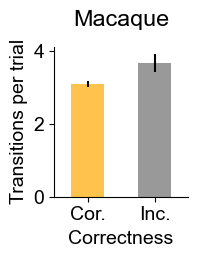

In [14]:
df = pd.DataFrame({
    'num_transitions': num_transitions,
    'correctness': correctness,
    'session_id': session_id,
})

df_grouped = df.groupby(['correctness', 'session_id']).mean().reset_index()
means = df_grouped.groupby(['correctness']).mean().reset_index()
errors = (df_grouped.groupby(['correctness']).std() / np.sqrt(len(np.unique(df['session_id'])))).reset_index()

plt.figure(figsize = (2.2, 2.8))
plt.bar(['Cor.', 'Inc.'], means['num_transitions'][::-1], color = ['#FFC34D', '#999999'], width = 0.5, yerr = errors['num_transitions'][::-1], capsize = 0)
plt.xlim(-0.5, 1.5)
plt.xlabel('Correctness')
plt.ylabel('Transitions per trial')
plt.title('Macaque', pad = 15)
plt.tight_layout()
# plt.show()
plt.savefig('figures/p_num_transitions_by_correctness.pdf', bbox_inches = 'tight')

In [15]:
from scipy.stats import ttest_rel

# pivot the dataframe so each session_id has two columns: True and False
df_pivot = df_grouped.pivot(index = 'session_id', columns = 'correctness', values = 'num_transitions')

# drop rows that have missing data (just in case)
df_pivot = df_pivot.dropna()

# run paired t-test
t_stat, p_val = ttest_rel(df_pivot[True], df_pivot[False])

print(f't = {t_stat:.3f}, p = {p_val:.3g}')
print(len(df_pivot) - 1)

t = -2.768, p = 0.00835
42
